# ONLINE LEARNING APPLICATIONS - Course Project

## Riccardo Piantoni

### A.Y. 2025/2026

In [19]:
%load_ext autoreload
%autoreload 2

import numpy as np

import matplotlib.pyplot as plt

#from advertising_market_simulator import AdvertisementMarketSimulator
from environment.environment import Environment
from experiment import Experiment
from campaigns.uniform_bids_stochastic_campaign import UniformBidsStochasticCampaign
from bidders.UCB_based.combinatorial_ucb_like_bidder import CombinatorialUCBLikeBidder

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Requirement 2: Multiple campaigns and stochastic environment

### Environment

Build a stochastic environment:
- A joint distribution over the highest competing bids for each campaign

Modeling assumptions: one way to do this is to simply define one Beta distribution (or multiple different ones) and sample for each campaign. However, it is very likely that bids are correlated with each other. 

Questions:
- For which reason are they correlated though?
- How does this correlation reflect on the bids?

In [20]:
N_TRIALS = 2  # trials for proper curve estimation

BIDS_SPACE = np.linspace(0.0, 1.0, 11)  # possible bids = action space of size 10

# market = AdvertisementMarketSimulator()
environment = Environment(BIDS_SPACE)
environment.generate_random_campaigns(n_campaigns=3, campaign_type=UniformBidsStochasticCampaign, min_competitors=3, max_competitors=5, conflicts_percentage=0.4, seed=47)  # generate a single campaign with random qualities for each advertisers
print(environment)

N_USERS = 1000  # number of ads to be shown sequentially = n_rounds = T

RHO = 0.15  # budget per round -> define either rho or the starting budget B and derive the other (rho = B/T)

-- ENVIRONMENT: --
Bids space: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Number of campaigns: 3
Campaigns:
    -- CAMPAIGN: --
    Type: Uniform Bids
    Description: Competing bids sampled from a stochastic uniform distribution, maximum bid follows a Beta distribution.
    Ad qualities: [1. 1. 1. 1. 1. 1.]
    Number of advertisers: 6
    Number of competitors: 5
    -- CAMPAIGN: --
    Type: Uniform Bids
    Description: Competing bids sampled from a stochastic uniform distribution, maximum bid follows a Beta distribution.
    Ad qualities: [1. 1. 1. 1.]
    Number of advertisers: 4
    Number of competitors: 3
    -- CAMPAIGN: --
    Type: Uniform Bids
    Description: Competing bids sampled from a stochastic uniform distribution, maximum bid follows a Beta distribution.
    Ad qualities: [1. 1. 1. 1.]
    Number of advertisers: 4
    Number of competitors: 3
Conflicts graph matrix (1 = conflicting):
[[0 1 0]
 [1 0 0]
 [0 0 0]]


### Design algorithms for multiple campaigns and stochastic environment

- Build a bidding strategy using Combinatorial-UCB with budget constraint.

Hint: Extend the “UCB-like” approach that we saw for a single campaign to multiple
campaigns.

Questions:
- Okay, but there is no notion of pacing in the UCB-like approach, no? -> No, because pacing makes sense when you act in a non-stationary environment, otherwise if it stationary there is no reason why you should pace yourself, since later auctions are going to be the same as earlier ones. And a stochastic environment is stationary 

Clairvoyant - combinatorial over campaigns - simple version
campaign_phase_change_times: [array([0], dtype=int64), array([0], dtype=int64), array([0], dtype=int64)]
joined_phase_change_times: [0]
joined_indices: [array([0], dtype=int64), array([0], dtype=int64), array([0], dtype=int64)]
campaign_gamma_values: [array([[0., 0., 0., 0., 0., 0., 1., 0.]]), array([[0., 0., 0., 0., 0., 1., 0., 0.]]), array([[0., 0., 0., 0., 0., 1., 0., 0.]])]
Clairvoyant - combinatorial over campaigns - simple version
campaign_phase_change_times: [array([0], dtype=int64), array([0], dtype=int64), array([0], dtype=int64)]
joined_phase_change_times: [0]
joined_indices: [array([0], dtype=int64), array([0], dtype=int64), array([0], dtype=int64)]
campaign_gamma_values: [array([[0., 0., 0., 0., 0., 0., 1., 0.]]), array([[0., 0., 0., 0., 0., 1., 0., 0.]]), array([[0., 0., 0., 0., 0., 1., 0., 0.]])]


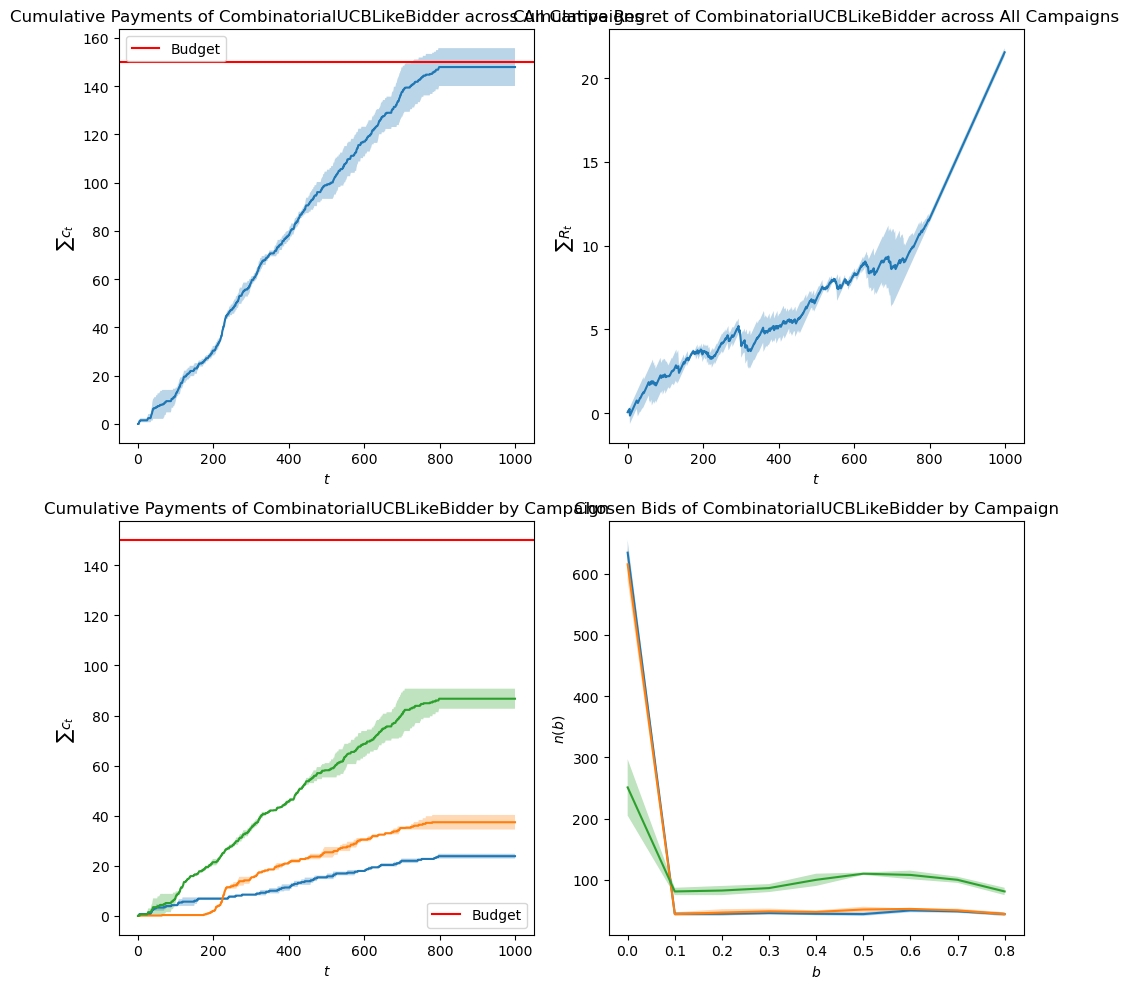

In [ ]:
STARTING_BUDGET = RHO * N_USERS     # or np.inf for no budget

MY_VALUATION = 0.8  # my true valuation of the ads (assumed to be known)

budget_constrained_single_campaign_combinatorial_UCB_like_experiment = Experiment(environment=environment,
                                                          bidder_class=CombinatorialUCBLikeBidder, 
                                                          bidder_parameters={
                                                              'B': STARTING_BUDGET, 
                                                              'T': N_USERS, 
                                                              'valuations': [MY_VALUATION for _ in range(environment.N_CAMPAIGNS)], 
                                                              'environment': environment
                                                            })

budget_constrained_single_campaign_combinatorial_UCB_like_experiment.run_trials(n_trials=N_TRIALS, clairvoyant_strategy_type='simple')